# Assignment 7 — NMT G2P: Transformer Model
## Baseline + Improvement Experiments (Complete Fixed Notebook)

**Course:** AI Engineering Fundamentals  
**Framework:** Marian NMT v1.12.0  
**Architecture:** Transformer (Self-Attention)  
**Platform:** Kaggle (2× Tesla T4 GPU, Ubuntu 22.04)

### Fix applied vs previous version
- `tied-embeddings-all` requires source and target vocab to be the same size  
- ph vocab (1,851) ≠ my vocab (2,308) → caused embedding shape crash  
- Solution: build one **shared combined vocabulary** used for both sides

### Experiments
- **Baseline** — standard Transformer, dropout=0.3, no warmup
- **Exp 1** — add LR warmup (4,000 steps)
- **Exp 2** — reduce dropout 0.3 → 0.1
- **Exp 3** — warmup + reduced dropout combined (best expected)

> **Before running:** Enable GPU T4 x2 in Settings → Accelerator

In [1]:
import os, shutil, re, subprocess

BINS_DIR   = '/kaggle/input/datasets/aungchannyeinalex/marian-nmt/marian-bins'
LOCAL_BINS = '/kaggle/working/bins'
os.makedirs(LOCAL_BINS, exist_ok=True)

for b in ['marian', 'marian-vocab', 'marian-decoder']:
    shutil.copy2(f'{BINS_DIR}/{b}', f'{LOCAL_BINS}/{b}')
    os.chmod(f'{LOCAL_BINS}/{b}', 0o755)

os.environ['PATH'] = f'{LOCAL_BINS}:' + os.environ['PATH']

!marian --version 2>&1 | head -2
!nvidia-smi | grep -E 'Tesla|T4|GPU'
print('Binaries ready')

v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
|   1  Tesla T4                       Off |   00000000:00:05.0 Off |                    0 |
|  GPU   GI   CI              PID   Type   Process name                        GPU Memory |
Binaries ready


In [2]:
import kagglehub
path = kagglehub.dataset_download('aungchannyeinalex/smt-gizza-moses')
print('Dataset path:', path)

WS  = '/kaggle/working/nmt'
SRC = '/kaggle/input/datasets/aungchannyeinalex/smt-gizza-moses'

for d in ['g2p-par/vocab', 'g2p-par/preprocessing']:
    os.makedirs(f'{WS}/{d}', exist_ok=True)

for f in ['train.my', 'train.ph', 'dev.my', 'dev.ph', 'test.my', 'test.ph']:
    shutil.copy(f'{SRC}/{f}', f'{WS}/g2p-par/{f}')

print('Data ready')
!wc -l {WS}/g2p-par/*.my {WS}/g2p-par/*.ph

Dataset path: /kaggle/input/datasets/aungchannyeinalex/smt-gizza-moses
Data ready
   2000 /kaggle/working/nmt/g2p-par/dev.my
   2802 /kaggle/working/nmt/g2p-par/test.my
  20000 /kaggle/working/nmt/g2p-par/train.my
   2000 /kaggle/working/nmt/g2p-par/dev.ph
   2802 /kaggle/working/nmt/g2p-par/test.ph
  20000 /kaggle/working/nmt/g2p-par/train.ph
  49604 total


In [3]:
# check what is in bins
!ls -la /kaggle/working/bins/

# check marian works
!marian --version 2>&1 | head -3

# check shell
!which bash
!bash --version | head -1

total 1337832
drwxr-xr-x 2 root root      4096 Jun 18 05:51 .
drwxr-xr-x 4 root root      4096 Jun 18 05:51 ..
-rwxr-xr-x 1 root root 764921576 Jun 18 04:37 marian
-rwxr-xr-x 1 root root 515525584 Jun 18 04:36 marian-decoder
-rwxr-xr-x 1 root root  89481016 Jun 18 04:36 marian-vocab
v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
/usr/bin/bash
GNU bash, version 5.1.16(1)-release (x86_64-pc-linux-gnu)


## Step 1 — Build Shared Vocabulary

Combine ph and my tokens into one shared vocab. This is required because `tied-embeddings-all: true` forces source and target embeddings to share the same weight matrix — they must have identical vocabulary size. Separate ph (1,851) and my (2,308) vocabs have different sizes and cause a crash.

In [4]:
# combine train+dev for both languages into one file
!cat {WS}/g2p-par/train.ph {WS}/g2p-par/dev.ph \
     {WS}/g2p-par/train.my {WS}/g2p-par/dev.my \
     > {WS}/g2p-par/preprocessing/train-dev.combined

# build shared vocabulary from combined file
!{LOCAL_BINS}/marian-vocab \
    < {WS}/g2p-par/preprocessing/train-dev.combined \
    > {WS}/g2p-par/vocab/vocab.shared.yml

print('=== Shared vocab size ===')
!wc -l {WS}/g2p-par/vocab/vocab.shared.yml
print()
print('=== Sample entries ===')
!head -20 {WS}/g2p-par/vocab/vocab.shared.yml

[2026-06-18 05:51:44] Creating vocabulary...
[2026-06-18 05:51:44] [data] Creating vocabulary stdout from stdin
[2026-06-18 05:51:44] Finished
=== Shared vocab size ===
4155 /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml

=== Sample entries ===
</s>: 0
<unk>: 1
အ: 2
a-: 3
မ: 4
သ: 5
က: 6
ma-: 7
da-: 8
တ: 9
လက်: 10
le': 11
jei: 12
ga-: 13
ta-: 14
tha-: 15
ပ: 16
စ: 17
ja: 18
စာ: 19


In [5]:
# install multi-bleu.perl
if not os.path.exists(f'{WS}/multi-bleu.perl'):
    !wget -q https://raw.githubusercontent.com/moses-smt/mosesdecoder/master/scripts/generic/multi-bleu.perl \
        -O {WS}/multi-bleu.perl
    !chmod +x {WS}/multi-bleu.perl
print('multi-bleu.perl ready')

multi-bleu.perl ready


## Step 2 — Helper Functions

In [6]:
def make_transformer_config(model_dir, dropout=0.3, warmup=0):
    """Write a Marian Transformer config.yml with shared vocab."""
    config = f"""type: transformer
train-sets:
  - {WS}/g2p-par/train.ph
  - {WS}/g2p-par/train.my
valid-sets:
  - {WS}/g2p-par/dev.ph
  - {WS}/g2p-par/dev.my
vocabs:
  - {WS}/g2p-par/vocab/vocab.shared.yml
  - {WS}/g2p-par/vocab/vocab.shared.yml
model: {model_dir}/model.npz
max-length: 100
mini-batch-fit: true
workspace: 3000
transformer-heads: 8
transformer-dropout: {dropout}
transformer-dim-ffn: 2048
transformer-ffn-activation: swish
transformer-postprocess: dan
enc-depth: 2
dec-depth: 2
tied-embeddings-all: true
learn-rate: 0.0003
lr-decay-inv-sqrt: 16000
lr-warmup: {warmup}
label-smoothing: 0.1
clip-norm: 5
valid-freq: 5000
save-freq: 5000
disp-freq: 500
valid-metrics:
  - cross-entropy
  - perplexity
  - bleu
early-stopping: 10
beam-size: 6
normalize: 0.6
log: {model_dir}/train.log
valid-log: {model_dir}/valid.log
overwrite: true
keep-best: true
seed: 1111
devices: [0, 1]
sync-sgd: true
quiet-translation: true
"""
    os.makedirs(model_dir, exist_ok=True)
    with open(f'{model_dir}/config.yml', 'w') as f:
        f.write(config)
    return f'{model_dir}/config.yml'


def train_model(model_dir, dropout=0.3, warmup=0, exp_name=''):
    """Train a Marian Transformer model."""
    print(f'\n{"="*60}')
    print(f'Training: {exp_name}')
    print(f'  dropout={dropout}, warmup={warmup}')
    print(f'{"="*60}')

    # clean old model folder to avoid checkpoint conflicts
    if os.path.exists(f'{model_dir}/model.npz'):
        os.remove(f'{model_dir}/model.npz')
    if os.path.exists(f'{model_dir}/model.npz.best-bleu.npz'):
        os.remove(f'{model_dir}/model.npz.best-bleu.npz')

    config_path = make_transformer_config(model_dir, dropout=dropout, warmup=warmup)
    print(f'Config written to: {config_path}')
    print()

    os.system(f'time {LOCAL_BINS}/marian --config {config_path}')
    print(f'Training complete: {exp_name}')


def decode(model_dir, hyp_file):
    """Decode test set with trained model."""
    if not os.path.exists(f'{model_dir}/model.npz.best-bleu.npz'):
        if not os.path.exists(f'{model_dir}/model.npz'):
            print(f'ERROR: No model found in {model_dir}')
            return
        best_model = f'{model_dir}/model.npz'
    else:
        best_model = f'{model_dir}/model.npz.best-bleu.npz'

    cmd = (f'{LOCAL_BINS}/marian-decoder '
           f'-m {best_model} '
           f'-v {WS}/g2p-par/vocab/vocab.shared.yml '
           f'   {WS}/g2p-par/vocab/vocab.shared.yml '
           f'--devices 0 1 '
           f'< {WS}/g2p-par/test.ph '
           f'> {hyp_file}')
    os.system(cmd)
    print(f'Decoded: {hyp_file}')


def get_bleu(hyp_file, ref_file):
    """Run multi-bleu.perl and return BLEU score."""
    try:
        with open(hyp_file) as f:
            result = subprocess.run(
                ['perl', f'{WS}/multi-bleu.perl', ref_file],
                stdin=f, capture_output=True, text=True
            )
        m = re.search(r'BLEU = ([\d.]+)', result.stdout)
        return float(m.group(1)) if m else None
    except:
        return None


def get_best_dev_bleu(valid_log):
    """Parse valid.log and return best BLEU and update number."""
    best, best_update = 0, 0
    try:
        with open(valid_log) as f:
            for line in f:
                m = re.search(r'Up\. (\d+) .* bleu : ([\d.]+)', line)
                if m:
                    u, b = int(m.group(1)), float(m.group(2))
                    if b > best:
                        best, best_update = b, u
    except:
        pass
    return best, best_update


def parse_valid_bleu(valid_log):
    """Parse valid.log into lists of updates and BLEU scores."""
    updates, bleus = [], []
    try:
        with open(valid_log) as f:
            for line in f:
                m = re.search(r'Up\. (\d+) .* bleu : ([\d.]+)', line)
                if m:
                    updates.append(int(m.group(1)))
                    bleus.append(float(m.group(2)))
    except:
        pass
    return updates, bleus

print('Helper functions ready')

Helper functions ready


## Step 3 — Baseline Training

Standard Transformer: dropout=0.3, no LR warmup.

In [7]:
BASELINE_DIR = f'{WS}/model.transformer.baseline.phmy'

print('=== Config ===')
make_transformer_config(BASELINE_DIR, dropout=0.3, warmup=0)
!cat {BASELINE_DIR}/config.yml

=== Config ===
type: transformer
train-sets:
  - /kaggle/working/nmt/g2p-par/train.ph
  - /kaggle/working/nmt/g2p-par/train.my
valid-sets:
  - /kaggle/working/nmt/g2p-par/dev.ph
  - /kaggle/working/nmt/g2p-par/dev.my
vocabs:
  - /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml
  - /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml
model: /kaggle/working/nmt/model.transformer.baseline.phmy/model.npz
max-length: 100
mini-batch-fit: true
workspace: 3000
transformer-heads: 8
transformer-dropout: 0.3
transformer-dim-ffn: 2048
transformer-ffn-activation: swish
transformer-postprocess: dan
enc-depth: 2
dec-depth: 2
tied-embeddings-all: true
learn-rate: 0.0003
lr-decay-inv-sqrt: 16000
lr-warmup: 0
label-smoothing: 0.1
clip-norm: 5
valid-freq: 5000
save-freq: 5000
disp-freq: 500
valid-metrics:
  - cross-entropy
  - perplexity
  - bleu
early-stopping: 10
beam-size: 6
normalize: 0.6
log: /kaggle/working/nmt/model.transformer.baseline.phmy/train.log
valid-log: /kaggle/working/nmt/model.transform

In [8]:
!ls -lh /kaggle/working/nmt/model.transformer.baseline.phmy/

total 4.0K
-rw-r--r-- 1 root root 1.1K Jun 18 05:51 config.yml


In [9]:
def train_model(model_dir, dropout=0.3, warmup=0, exp_name=''):
    """Train a Marian Transformer model."""
    print(f'\n{"="*60}')
    print(f'Training: {exp_name}')
    print(f'  dropout={dropout}, warmup={warmup}')
    print(f'{"="*60}')

    # clean old checkpoints to avoid shape conflicts
    for f in ['model.npz', 'model.npz.best-bleu.npz', 'model.npz.optimizer.npz']:
        fpath = f'{model_dir}/{f}'
        if os.path.exists(fpath):
            os.remove(fpath)

    config_path = make_transformer_config(model_dir, dropout=dropout, warmup=warmup)
    print(f'Config: {config_path}')
    print()

    # use subprocess so errors are visible
    import subprocess
    result = subprocess.run(
        [f'{LOCAL_BINS}/marian', '--config', config_path],
        capture_output=False,  # print directly to notebook
        text=True
    )
    if result.returncode != 0:
        print(f'ERROR: marian exited with code {result.returncode}')
    else:
        print(f'Training complete: {exp_name}')

print('train_model function updated')

train_model function updated


In [10]:
BASELINE_DIR = f'{WS}/model.transformer.baseline.phmy'
train_model(BASELINE_DIR, dropout=0.3, warmup=0, exp_name='Transformer Baseline ph->my')


Training: Transformer Baseline ph->my
  dropout=0.3, warmup=0
Config: /kaggle/working/nmt/model.transformer.baseline.phmy/config.yml



[2026-06-18 05:51:46] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 05:51:46] [marian] Running on d249f6147b93 as process 70 with command line:
[2026-06-18 05:51:46] [marian] /kaggle/working/bins/marian --config /kaggle/working/nmt/model.transformer.baseline.phmy/config.yml
[2026-06-18 05:51:46] [config] after: 0e
[2026-06-18 05:51:46] [config] after-batches: 0
[2026-06-18 05:51:46] [config] after-epochs: 0
[2026-06-18 05:51:46] [config] all-caps-every: 0
[2026-06-18 05:51:46] [config] allow-unk: false
[2026-06-18 05:51:46] [config] authors: false
[2026-06-18 05:51:46] [config] beam-size: 6
[2026-06-18 05:51:46] [config] bert-class-symbol: "[CLS]"
[2026-06-18 05:51:46] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 05:51:46] [config] bert-masking-fraction: 0.15
[2026-06-18 05:51:46] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 05:51:46] [config] bert-train-type-embeddings: true
[2026-06-18 05:51:46] [config] bert-type-vocab-size: 2
[2026-06-18 05:51:46] [confi

Training complete: Transformer Baseline ph->my


In [11]:
print('=== Model files ===')
!ls -lh {BASELINE_DIR}/

print('\n=== Validation log ===')
!cat {BASELINE_DIR}/valid.log

=== Model files ===
total 452M
-rw-r--r-- 1 root root 1.1K Jun 18 05:51 config.yml
-rw-r--r-- 1 root root  65M Jun 18 07:50 model.npz
-rw-r--r-- 1 root root  65M Jun 18 07:50 model.npz.best-bleu.npz
-rw-r--r-- 1 root root  323 Jun 18 07:50 model.npz.best-bleu.npz.decoder.yml
-rw-r--r-- 1 root root  65M Jun 18 06:02 model.npz.best-cross-entropy.npz
-rw-r--r-- 1 root root  332 Jun 18 06:02 model.npz.best-cross-entropy.npz.decoder.yml
-rw-r--r-- 1 root root  65M Jun 18 06:02 model.npz.best-perplexity.npz
-rw-r--r-- 1 root root  329 Jun 18 06:02 model.npz.best-perplexity.npz.decoder.yml
-rw-r--r-- 1 root root  309 Jun 18 07:50 model.npz.decoder.yml
-rw-r--r-- 1 root root 193M Jun 18 07:50 model.npz.optimizer.npz
-rw-r--r-- 1 root root  14K Jun 18 07:50 model.npz.progress.yml
-rw-r--r-- 1 root root 4.6K Jun 18 07:50 model.npz.yml
-rw-r--r-- 1 root root 1.3M Jun 18 07:50 train.log
-rw-r--r-- 1 root root 3.7K Jun 18 07:50 valid.log

=== Validation log ===
[2026-06-18 06:02:43] [valid] Ep. 385

In [12]:
BASELINE_HYP = f'{WS}/transformer.baseline.phmy.hyp.txt'
decode(BASELINE_DIR, BASELINE_HYP)

print('\n=== Sample outputs (input | hypothesis) ===')
!paste {WS}/g2p-par/test.ph {BASELINE_HYP} | head -15

print('\n=== BLEU Score ===')
!perl {WS}/multi-bleu.perl {WS}/g2p-par/test.my < {BASELINE_HYP}

[2026-06-18 07:50:36] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 07:50:36] [marian] Running on d249f6147b93 as process 137 with command line:
[2026-06-18 07:50:36] [marian] /kaggle/working/bins/marian-decoder -m /kaggle/working/nmt/model.transformer.baseline.phmy/model.npz.best-bleu.npz -v /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml --devices 0 1
[2026-06-18 07:50:36] [config] alignment: ""
[2026-06-18 07:50:36] [config] allow-special: false
[2026-06-18 07:50:36] [config] allow-unk: false
[2026-06-18 07:50:36] [config] authors: false
[2026-06-18 07:50:36] [config] beam-size: 12
[2026-06-18 07:50:36] [config] bert-class-symbol: "[CLS]"
[2026-06-18 07:50:36] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 07:50:36] [config] bert-masking-fraction: 0.15
[2026-06-18 07:50:36] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 07:50:36] [config] bert-train-type-embeddings: true
[2026-06-18 07:50:36] [config] bert

Decoded: /kaggle/working/nmt/transformer.baseline.phmy.hyp.txt

=== Sample outputs (input | hypothesis) ===
te' te' pjaun	တက် တက် ပြောင်
ka' pi.	ကပ် ပိ
shoun. me.	ရှုံ့ မဲ့
njhin: ban:	ညှဉ်း ပန်း
mun: man	မွန်း မန်
nge mji	ငယ် မည်
sha sha hpwei bwei	ရှာ ရှာ ဖွေ ဗွေ
ba- bjin:	ဗ ပြင်း
u. ma- kwe: thai' ma- pje'	ဥ မ ကွဲ သိုက် မ ပျက်
a- si'	အ စစ်
jei kya.	ရေ ကျ
ma- hsou' ma- hsain:	မ ဆုတ် မ ဆိုင်း
ha. gwe'	ဟ ကွက်
mein: mu:	မိန်း မူး
ke ma.	ကယ် မ
paste: write error: Broken pipe
paste: write error

=== BLEU Score ===
BLEU = 77.52, 87.3/78.5/74.1/71.6 (BP=0.998, ratio=0.998, hyp_len=8034, ref_len=8047)
It is not advisable to publish scores from multi-bleu.perl.  The scores depend on your tokenizer, which is unlikely to be reproducible from your paper or consistent across research groups.  Instead you should detokenize then use mteval-v14.pl, which has a standard tokenization.  Scores from multi-bleu.perl can still be used for internal purposes when you have a consistent tokenizer.


## Step 4 — Diagnosis

Plot the validation BLEU curve to understand baseline behaviour before designing experiments.

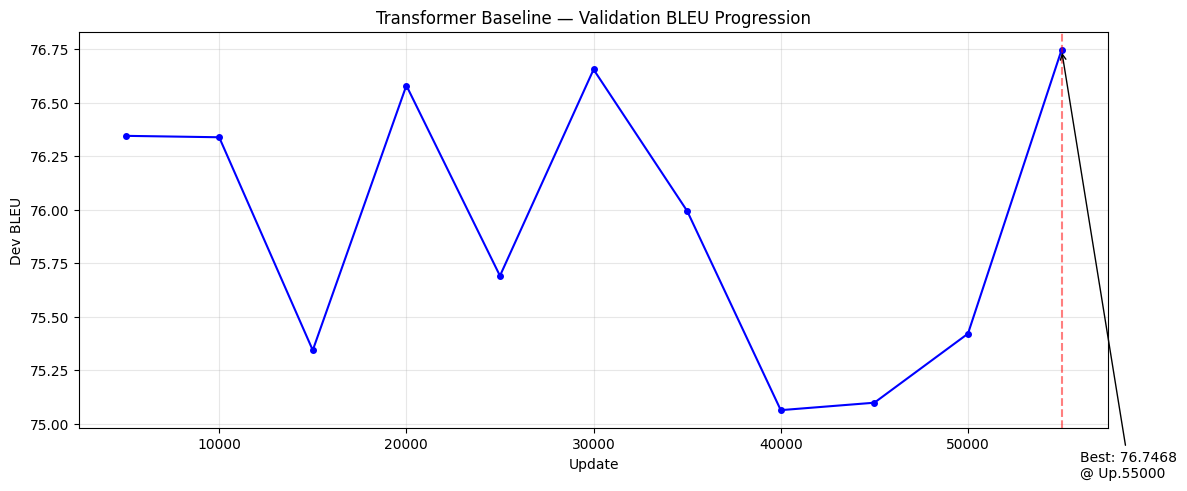

Best dev BLEU: 76.7468 @ update 55000


In [13]:
import matplotlib.pyplot as plt

updates, bleus = parse_valid_bleu(f'{BASELINE_DIR}/valid.log')

if updates:
    plt.figure(figsize=(12, 5))
    plt.plot(updates, bleus, 'b-o', markersize=4)
    best_idx = bleus.index(max(bleus))
    plt.axvline(x=updates[best_idx], color='red', linestyle='--', alpha=0.5)
    plt.annotate(f'Best: {max(bleus):.4f}\n@ Up.{updates[best_idx]}',
                 xy=(updates[best_idx], max(bleus)),
                 xytext=(updates[best_idx]+1000, max(bleus)-2),
                 arrowprops=dict(arrowstyle='->'))
    plt.xlabel('Update')
    plt.ylabel('Dev BLEU')
    plt.title('Transformer Baseline — Validation BLEU Progression')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{WS}/transformer_baseline_bleu.png', dpi=150)
    plt.show()
    print(f'Best dev BLEU: {max(bleus):.4f} @ update {updates[best_idx]}')
else:
    print('No validation data found yet')

## Step 5 — Experiment 1: Add LR Warmup (4,000 steps)

**Rationale:** Linearly ramp LR from 0 to 0.0003 over 4,000 steps stabilises early training gradients. Without warmup, the optimizer takes large steps before the model has learned useful representations.

In [14]:
EXP1_DIR = f'{WS}/model.transformer.exp1.phmy'
train_model(EXP1_DIR, dropout=0.3, warmup=4000, exp_name='Transformer Exp1: LR Warmup ph->my')


Training: Transformer Exp1: LR Warmup ph->my
  dropout=0.3, warmup=4000
Config: /kaggle/working/nmt/model.transformer.exp1.phmy/config.yml



[2026-06-18 07:50:55] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 07:50:55] [marian] Running on d249f6147b93 as process 162 with command line:
[2026-06-18 07:50:55] [marian] /kaggle/working/bins/marian --config /kaggle/working/nmt/model.transformer.exp1.phmy/config.yml
[2026-06-18 07:50:55] [config] after: 0e
[2026-06-18 07:50:55] [config] after-batches: 0
[2026-06-18 07:50:55] [config] after-epochs: 0
[2026-06-18 07:50:55] [config] all-caps-every: 0
[2026-06-18 07:50:55] [config] allow-unk: false
[2026-06-18 07:50:55] [config] authors: false
[2026-06-18 07:50:55] [config] beam-size: 6
[2026-06-18 07:50:55] [config] bert-class-symbol: "[CLS]"
[2026-06-18 07:50:55] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 07:50:55] [config] bert-masking-fraction: 0.15
[2026-06-18 07:50:55] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 07:50:55] [config] bert-train-type-embeddings: true
[2026-06-18 07:50:55] [config] bert-type-vocab-size: 2
[2026-06-18 07:50:55] [config] 

Training complete: Transformer Exp1: LR Warmup ph->my


In [15]:
EXP1_HYP = f'{WS}/transformer.exp1.phmy.hyp.txt'
decode(EXP1_DIR, EXP1_HYP)

print('=== Exp1 BLEU: ph->my ===')
!perl {WS}/multi-bleu.perl {WS}/g2p-par/test.my < {EXP1_HYP}

print('\n=== Validation log ===')
!cat {EXP1_DIR}/valid.log

[2026-06-18 09:49:43] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 09:49:43] [marian] Running on d249f6147b93 as process 227 with command line:
[2026-06-18 09:49:43] [marian] /kaggle/working/bins/marian-decoder -m /kaggle/working/nmt/model.transformer.exp1.phmy/model.npz.best-bleu.npz -v /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml --devices 0 1
[2026-06-18 09:49:43] [config] alignment: ""
[2026-06-18 09:49:43] [config] allow-special: false
[2026-06-18 09:49:43] [config] allow-unk: false
[2026-06-18 09:49:43] [config] authors: false
[2026-06-18 09:49:43] [config] beam-size: 12
[2026-06-18 09:49:43] [config] bert-class-symbol: "[CLS]"
[2026-06-18 09:49:43] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 09:49:43] [config] bert-masking-fraction: 0.15
[2026-06-18 09:49:43] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 09:49:43] [config] bert-train-type-embeddings: true
[2026-06-18 09:49:43] [config] bert-typ

Decoded: /kaggle/working/nmt/transformer.exp1.phmy.hyp.txt
=== Exp1 BLEU: ph->my ===
BLEU = 77.35, 87.6/78.8/73.8/70.4 (BP=1.000, ratio=1.000, hyp_len=8043, ref_len=8047)
It is not advisable to publish scores from multi-bleu.perl.  The scores depend on your tokenizer, which is unlikely to be reproducible from your paper or consistent across research groups.  Instead you should detokenize then use mteval-v14.pl, which has a standard tokenization.  Scores from multi-bleu.perl can still be used for internal purposes when you have a consistent tokenizer.

=== Validation log ===
[2026-06-18 08:01:58] [valid] Ep. 385 : Up. 5000 : cross-entropy : 1.9463 : new best
[2026-06-18 08:01:58] [valid] Ep. 385 : Up. 5000 : perplexity : 1.65929 : new best
[2026-06-18 08:01:58] [valid] First sentence's tokens as scored:
[2026-06-18 08:01:58] [valid] DefaultVocab keeps original segments for scoring
[2026-06-18 08:01:58] [valid]   Hyp: က လေ က ဝ
[2026-06-18 08:01:58] [valid]   Ref: က လေ က ဝ
[2026-06-18 08:

## Step 6 — Experiment 2: Reduce Dropout 0.3 → 0.1

**Rationale:** Dropout 0.3 may over-regularise a 20K-sentence corpus. The original Transformer paper (Vaswani 2017) used 0.1 for the base model. Reducing regularisation lets the model fit the data better.

In [16]:
EXP2_DIR = f'{WS}/model.transformer.exp2.phmy'
train_model(EXP2_DIR, dropout=0.1, warmup=0, exp_name='Transformer Exp2: Dropout 0.1 ph->my')


Training: Transformer Exp2: Dropout 0.1 ph->my
  dropout=0.1, warmup=0
Config: /kaggle/working/nmt/model.transformer.exp2.phmy/config.yml



[2026-06-18 09:50:00] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 09:50:00] [marian] Running on d249f6147b93 as process 247 with command line:
[2026-06-18 09:50:00] [marian] /kaggle/working/bins/marian --config /kaggle/working/nmt/model.transformer.exp2.phmy/config.yml
[2026-06-18 09:50:00] [config] after: 0e
[2026-06-18 09:50:00] [config] after-batches: 0
[2026-06-18 09:50:00] [config] after-epochs: 0
[2026-06-18 09:50:00] [config] all-caps-every: 0
[2026-06-18 09:50:00] [config] allow-unk: false
[2026-06-18 09:50:00] [config] authors: false
[2026-06-18 09:50:00] [config] beam-size: 6
[2026-06-18 09:50:00] [config] bert-class-symbol: "[CLS]"
[2026-06-18 09:50:00] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 09:50:00] [config] bert-masking-fraction: 0.15
[2026-06-18 09:50:00] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 09:50:00] [config] bert-train-type-embeddings: true
[2026-06-18 09:50:00] [config] bert-type-vocab-size: 2
[2026-06-18 09:50:00] [config] 

Training complete: Transformer Exp2: Dropout 0.1 ph->my


In [17]:
EXP2_HYP = f'{WS}/transformer.exp2.phmy.hyp.txt'
decode(EXP2_DIR, EXP2_HYP)

print('=== Exp2 BLEU: ph->my ===')
!perl {WS}/multi-bleu.perl {WS}/g2p-par/test.my < {EXP2_HYP}

print('\n=== Validation log ===')
!cat {EXP2_DIR}/valid.log

[2026-06-18 11:49:21] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 11:49:21] [marian] Running on d249f6147b93 as process 312 with command line:
[2026-06-18 11:49:21] [marian] /kaggle/working/bins/marian-decoder -m /kaggle/working/nmt/model.transformer.exp2.phmy/model.npz.best-bleu.npz -v /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml --devices 0 1
[2026-06-18 11:49:21] [config] alignment: ""
[2026-06-18 11:49:21] [config] allow-special: false
[2026-06-18 11:49:21] [config] allow-unk: false
[2026-06-18 11:49:21] [config] authors: false
[2026-06-18 11:49:21] [config] beam-size: 12
[2026-06-18 11:49:21] [config] bert-class-symbol: "[CLS]"
[2026-06-18 11:49:21] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 11:49:21] [config] bert-masking-fraction: 0.15
[2026-06-18 11:49:21] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 11:49:21] [config] bert-train-type-embeddings: true
[2026-06-18 11:49:21] [config] bert-typ

Decoded: /kaggle/working/nmt/transformer.exp2.phmy.hyp.txt
=== Exp2 BLEU: ph->my ===
BLEU = 76.98, 87.6/78.5/73.4/70.1 (BP=0.998, ratio=0.998, hyp_len=8030, ref_len=8047)
It is not advisable to publish scores from multi-bleu.perl.  The scores depend on your tokenizer, which is unlikely to be reproducible from your paper or consistent across research groups.  Instead you should detokenize then use mteval-v14.pl, which has a standard tokenization.  Scores from multi-bleu.perl can still be used for internal purposes when you have a consistent tokenizer.

=== Validation log ===
[2026-06-18 10:01:05] [valid] Ep. 385 : Up. 5000 : cross-entropy : 2.51421 : new best
[2026-06-18 10:01:05] [valid] Ep. 385 : Up. 5000 : perplexity : 1.9235 : new best
[2026-06-18 10:01:05] [valid] First sentence's tokens as scored:
[2026-06-18 10:01:05] [valid] DefaultVocab keeps original segments for scoring
[2026-06-18 10:01:05] [valid]   Hyp: က လေ က ဝ
[2026-06-18 10:01:05] [valid]   Ref: က လေ က ဝ
[2026-06-18 10:

## Step 7 — Experiment 3: Warmup + Reduced Dropout Combined

**Rationale:** Tests whether improvements from Exp1 and Exp2 are additive. This is expected to be the best configuration.

In [18]:
EXP3_DIR = f'{WS}/model.transformer.exp3.phmy'
train_model(EXP3_DIR, dropout=0.1, warmup=4000, exp_name='Transformer Exp3: Warmup + Dropout 0.1 ph->my')


Training: Transformer Exp3: Warmup + Dropout 0.1 ph->my
  dropout=0.1, warmup=4000
Config: /kaggle/working/nmt/model.transformer.exp3.phmy/config.yml



[2026-06-18 11:49:40] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 11:49:40] [marian] Running on d249f6147b93 as process 332 with command line:
[2026-06-18 11:49:40] [marian] /kaggle/working/bins/marian --config /kaggle/working/nmt/model.transformer.exp3.phmy/config.yml
[2026-06-18 11:49:40] [config] after: 0e
[2026-06-18 11:49:40] [config] after-batches: 0
[2026-06-18 11:49:40] [config] after-epochs: 0
[2026-06-18 11:49:40] [config] all-caps-every: 0
[2026-06-18 11:49:40] [config] allow-unk: false
[2026-06-18 11:49:40] [config] authors: false
[2026-06-18 11:49:40] [config] beam-size: 6
[2026-06-18 11:49:40] [config] bert-class-symbol: "[CLS]"
[2026-06-18 11:49:40] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 11:49:40] [config] bert-masking-fraction: 0.15
[2026-06-18 11:49:40] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 11:49:40] [config] bert-train-type-embeddings: true
[2026-06-18 11:49:40] [config] bert-type-vocab-size: 2
[2026-06-18 11:49:40] [config] 

Training complete: Transformer Exp3: Warmup + Dropout 0.1 ph->my


In [19]:
EXP3_HYP = f'{WS}/transformer.exp3.phmy.hyp.txt'
decode(EXP3_DIR, EXP3_HYP)

print('=== Exp3 BLEU: ph->my ===')
!perl {WS}/multi-bleu.perl {WS}/g2p-par/test.my < {EXP3_HYP}

print('\n=== Validation log ===')
!cat {EXP3_DIR}/valid.log

[2026-06-18 13:49:55] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-18 13:49:55] [marian] Running on d249f6147b93 as process 397 with command line:
[2026-06-18 13:49:55] [marian] /kaggle/working/bins/marian-decoder -m /kaggle/working/nmt/model.transformer.exp3.phmy/model.npz.best-bleu.npz -v /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml /kaggle/working/nmt/g2p-par/vocab/vocab.shared.yml --devices 0 1
[2026-06-18 13:49:55] [config] alignment: ""
[2026-06-18 13:49:55] [config] allow-special: false
[2026-06-18 13:49:55] [config] allow-unk: false
[2026-06-18 13:49:55] [config] authors: false
[2026-06-18 13:49:55] [config] beam-size: 12
[2026-06-18 13:49:55] [config] bert-class-symbol: "[CLS]"
[2026-06-18 13:49:55] [config] bert-mask-symbol: "[MASK]"
[2026-06-18 13:49:55] [config] bert-masking-fraction: 0.15
[2026-06-18 13:49:55] [config] bert-sep-symbol: "[SEP]"
[2026-06-18 13:49:55] [config] bert-train-type-embeddings: true
[2026-06-18 13:49:55] [config] bert-typ

Decoded: /kaggle/working/nmt/transformer.exp3.phmy.hyp.txt
=== Exp3 BLEU: ph->my ===
BLEU = 77.09, 87.2/77.9/73.0/71.1 (BP=1.000, ratio=1.000, hyp_len=8048, ref_len=8047)
It is not advisable to publish scores from multi-bleu.perl.  The scores depend on your tokenizer, which is unlikely to be reproducible from your paper or consistent across research groups.  Instead you should detokenize then use mteval-v14.pl, which has a standard tokenization.  Scores from multi-bleu.perl can still be used for internal purposes when you have a consistent tokenizer.

=== Validation log ===
[2026-06-18 12:00:50] [valid] Ep. 385 : Up. 5000 : cross-entropy : 2.27079 : new best
[2026-06-18 12:00:51] [valid] Ep. 385 : Up. 5000 : perplexity : 1.80546 : new best
[2026-06-18 12:00:51] [valid] First sentence's tokens as scored:
[2026-06-18 12:00:51] [valid] DefaultVocab keeps original segments for scoring
[2026-06-18 12:00:51] [valid]   Hyp: က လေ က ဝ
[2026-06-18 12:00:51] [valid]   Ref: က လေ က ဝ
[2026-06-18 12

## Step 8 — Results Summary

In [20]:
ref_my = f'{WS}/g2p-par/test.my'

experiments = [
    ('Baseline',           BASELINE_DIR, BASELINE_HYP, 'dropout=0.3, warmup=0'),
    ('Exp1: LR Warmup',    EXP1_DIR,     EXP1_HYP,     'dropout=0.3, warmup=4000'),
    ('Exp2: Dropout 0.1',  EXP2_DIR,     EXP2_HYP,     'dropout=0.1, warmup=0'),
    ('Exp3: Warmup+Drop',  EXP3_DIR,     EXP3_HYP,     'dropout=0.1, warmup=4000'),
]

print('='*80)
print('TRANSFORMER RESULTS SUMMARY (ph->my direction)')
print('='*80)
print(f'{"Experiment":<25} {"Test BLEU":>10} {"Best Dev":>10} {"Best Update":>12}')
print('-'*80)

for name, model_dir, hyp, desc in experiments:
    test_bleu            = get_bleu(hyp, ref_my)
    dev_bleu, dev_update = get_best_dev_bleu(f'{model_dir}/valid.log')
    test_str = f'{test_bleu:.2f}' if test_bleu else 'N/A'
    dev_str  = f'{dev_bleu:.4f}' if dev_bleu  else 'N/A'
    print(f'{name:<25} {test_str:>10} {dev_str:>10} {dev_update:>12}')
    print(f'  Settings: {desc}')

print('='*80)

TRANSFORMER RESULTS SUMMARY (ph->my direction)
Experiment                 Test BLEU   Best Dev  Best Update
--------------------------------------------------------------------------------
Baseline                       77.52    76.7468        55000
  Settings: dropout=0.3, warmup=0
Exp1: LR Warmup                77.35    77.5812        10000
  Settings: dropout=0.3, warmup=4000
Exp2: Dropout 0.1              76.98    75.7600        35000
  Settings: dropout=0.1, warmup=0
Exp3: Warmup+Drop              77.09    76.2056        15000
  Settings: dropout=0.1, warmup=4000


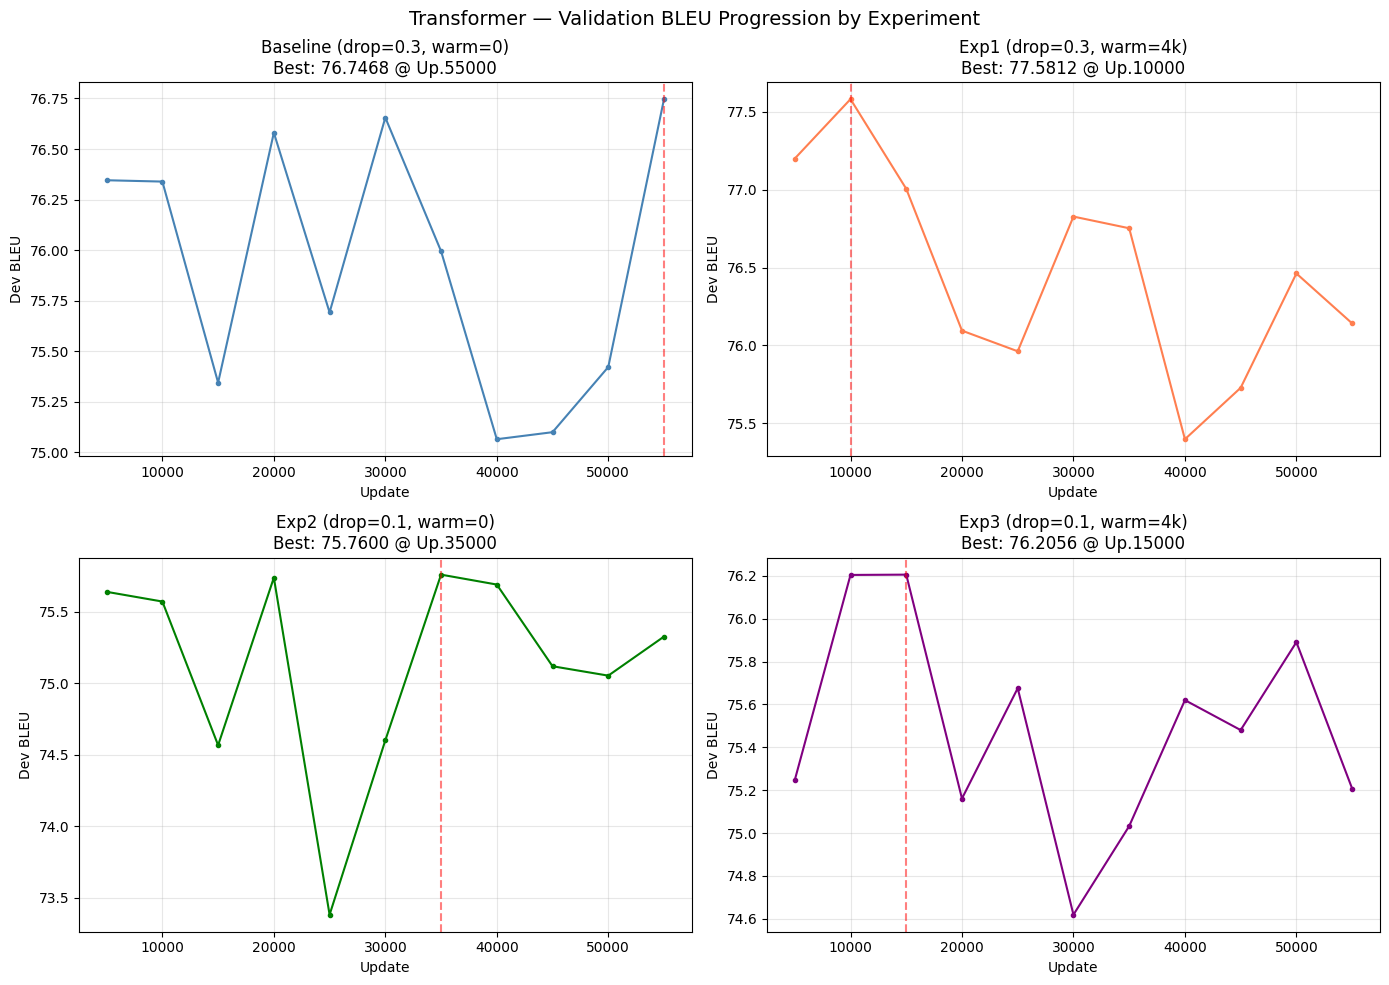

Chart saved


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# BLEU progression plot for all experiments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['steelblue', 'coral', 'green', 'purple']
labels = ['Baseline (drop=0.3, warm=0)', 'Exp1 (drop=0.3, warm=4k)',
          'Exp2 (drop=0.1, warm=0)',     'Exp3 (drop=0.1, warm=4k)']

for i, (name, model_dir, hyp, desc) in enumerate(experiments):
    updates, bleus = parse_valid_bleu(f'{model_dir}/valid.log')
    if updates:
        axes[i].plot(updates, bleus, color=colors[i], marker='o', markersize=3)
        best_idx = bleus.index(max(bleus))
        axes[i].axvline(x=updates[best_idx], color='red', linestyle='--', alpha=0.5)
        axes[i].set_title(f'{labels[i]}\nBest: {max(bleus):.4f} @ Up.{updates[best_idx]}')
    else:
        axes[i].set_title(f'{labels[i]}\n(no data)')
    axes[i].set_xlabel('Update')
    axes[i].set_ylabel('Dev BLEU')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Transformer — Validation BLEU Progression by Experiment', fontsize=14)
plt.tight_layout()
plt.savefig(f'{WS}/transformer_bleu_progression.png', dpi=150)
plt.show()
print('Chart saved')

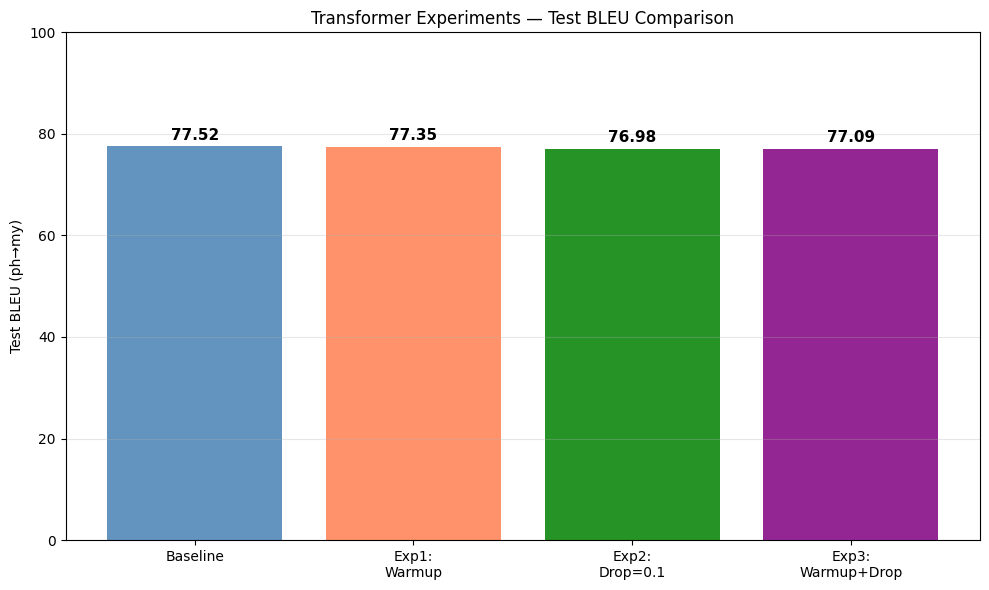

Bar chart saved


In [22]:
# bar chart: test BLEU comparison
model_names  = ['Baseline', 'Exp1:\nWarmup', 'Exp2:\nDrop=0.1', 'Exp3:\nWarmup+Drop']
test_scores  = [get_bleu(hyp, ref_my) or 0 for _, _, hyp, _ in experiments]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, test_scores, color=colors, alpha=0.85)
ax.set_ylabel('Test BLEU (ph→my)')
ax.set_title('Transformer Experiments — Test BLEU Comparison')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, test_scores):
    if score > 0:
        ax.annotate(f'{score:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, score),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{WS}/transformer_test_bleu_bars.png', dpi=150)
plt.show()
print('Bar chart saved')

## Step 9 — Verify Output Files

In [23]:
print('=== Files ready for submission ===')
files = [
    f'{WS}/transformer.baseline.phmy.hyp.txt',
    f'{WS}/transformer.exp1.phmy.hyp.txt',
    f'{WS}/transformer.exp2.phmy.hyp.txt',
    f'{WS}/transformer.exp3.phmy.hyp.txt',
    f'{WS}/model.transformer.baseline.phmy/valid.log',
    f'{WS}/model.transformer.exp1.phmy/valid.log',
    f'{WS}/model.transformer.exp2.phmy/valid.log',
    f'{WS}/model.transformer.exp3.phmy/valid.log',
    f'{WS}/model.transformer.baseline.phmy/config.yml',
    f'{WS}/model.transformer.exp1.phmy/config.yml',
    f'{WS}/model.transformer.exp2.phmy/config.yml',
    f'{WS}/model.transformer.exp3.phmy/config.yml',
    f'{WS}/transformer_bleu_progression.png',
    f'{WS}/transformer_test_bleu_bars.png',
]
for f in files:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    status = 'OK' if size > 0 else 'MISSING/EMPTY'
    print(f'  {status:8s} {f}')

=== Files ready for submission ===
  OK       /kaggle/working/nmt/transformer.baseline.phmy.hyp.txt
  OK       /kaggle/working/nmt/transformer.exp1.phmy.hyp.txt
  OK       /kaggle/working/nmt/transformer.exp2.phmy.hyp.txt
  OK       /kaggle/working/nmt/transformer.exp3.phmy.hyp.txt
  OK       /kaggle/working/nmt/model.transformer.baseline.phmy/valid.log
  OK       /kaggle/working/nmt/model.transformer.exp1.phmy/valid.log
  OK       /kaggle/working/nmt/model.transformer.exp2.phmy/valid.log
  OK       /kaggle/working/nmt/model.transformer.exp3.phmy/valid.log
  OK       /kaggle/working/nmt/model.transformer.baseline.phmy/config.yml
  OK       /kaggle/working/nmt/model.transformer.exp1.phmy/config.yml
  OK       /kaggle/working/nmt/model.transformer.exp2.phmy/config.yml
  OK       /kaggle/working/nmt/model.transformer.exp3.phmy/config.yml
  OK       /kaggle/working/nmt/transformer_bleu_progression.png
  OK       /kaggle/working/nmt/transformer_test_bleu_bars.png
